# Multi-Style Premia: Momentum and Value (Baz et al. 2015)

Baz, Harvey, Le Roux, Rattray, Van Hemert and Hofmann (2015) argue that the interesting part of style investing is not any single premium but the **low correlation between styles**. Combining time-series momentum, cross-sectional momentum, value and carry is, in their sample, a diversification story: imperfectly correlated sleeves let you vol-target the blend up and convert that diversification into return.

This notebook implements that architecture on the same 10-ETF, 2007–2024 book as the companion momentum notebooks, with two deliberate restrictions.

**Carry is omitted.** A proper carry signal is asset-class-specific (futures curve for commodities, rate differentials for FX, dividend yield for equities, curve slope for bonds). None of those are cleanly available for this ETF universe without a second data stack. Adding a junk carry proxy would not be implementing Baz et al.; it would be padding a correlation matrix.

**Value is the 5-year reversal**, the Asness–Moskowitz–Pedersen (2013) proxy used when book-to-market is not defined: cheap = the names with the worst trailing 5-year return. That specification needs five years of history, so the aligned sample starts in 2012. Twelve years is a weak sample for a style whose published evidence is measured in decades — we will check Ken French HML on the long monthly file as a sanity check, rather than declaring value dead from 10 ETFs in a growth bull market.

1. Time-series momentum (EWMA 32/96, vol-scaled) — same engine as `momentum_strategies.ipynb`
2. Cross-sectional momentum (12-1 month, AMP specification) and the companion 6-month variant
3. Cross-sectional value (5-year reversal, skip the most recent month so it does not overlap the momentum window)
4. Cross-style correlations and equal-volatility blends: momentum-only vs. momentum + value


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from IPython.display import display
from scipy import stats

TRADING_DAYS = 252
TARGET_VOL = 0.15
TOP_K = 3
MIN_NAMES = 10

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

csv_path = "real_market_data.csv"
tickers = ["SPY", "QQQ", "IWM", "EEM", "EFA", "TLT", "LQD", "GLD", "DBC", "VNQ"]
if os.path.exists(csv_path):
    df_prices = pd.read_csv(csv_path, index_col=0, parse_dates=True)
else:
    df_prices = yf.download(tickers, start="2007-01-01", end="2024-06-01")["Close"].dropna()
    df_prices.to_csv(csv_path)

df_returns = df_prices.pct_change()
print(f"Loaded {df_prices.index[0]:%Y-%m-%d} → {df_prices.index[-1]:%Y-%m-%d}")
print(f"Universe ({df_prices.shape[1]}): {list(df_prices.columns)}")
print(f"5-year lookback leaves ~{(len(df_prices) - 1260) / TRADING_DAYS:.1f} years of aligned value history")
print(f"Sharpe required for t = 2 over 12 years: {2 / np.sqrt(12):.2f}")


Loaded 2007-01-03 → 2024-05-31
Universe (10): ['DBC', 'EEM', 'EFA', 'GLD', 'IWM', 'LQD', 'QQQ', 'SPY', 'TLT', 'VNQ']
5-year lookback leaves ~12.4 years of aligned value history
Sharpe required for t = 2 over 12 years: 0.58


## 1. Style constructions

**Time-series momentum.** Per-asset sign of a 32/96 EWMA crossover, scaled to 15% asset-level volatility, equal-weighted across names, lagged one day. Portfolio-level vol targeting is applied afterwards so every sleeve is on the same 15% risk budget before blending.

**Cross-sectional momentum.** AMP's 12-1 construction: rank by the return from $t-252$ to $t-21$ (skip the most recent month, which is the short-term reversal interval). Long top 3 / short bottom 3, dollar-neutral, then vol-target the book. The companion notebook's 6-month rank is kept as a side-by-side; it is not the specification Baz/AMP use.

**Cross-sectional value.** Rank by the *negative* of the return from $t-1260$ to $t-21$. Long the 3 cheapest (largest 5-year losers), short the 3 most expensive. No position until all 10 names have a 5-year history — filling the leading window with zeros would look like a value book that does nothing for five years and flatten the Sharpe. Each sleeve's vol target also waits for 60 real returns before it applies any leverage, so the aligned window opens at the end of March 2012.

$$s^{\text{TSMOM}}_{i,t} = \operatorname{sign}(\text{EWMA}_{32}-\text{EWMA}_{96}), \quad
s^{\text{XSMOM}}_{i,t} = \operatorname{rank}(P_{t-21}/P_{t-252}-1), \quad
s^{\text{VAL}}_{i,t} = \operatorname{rank}\big(-(P_{t-21}/P_{t-1260}-1)\big)$$


In [2]:
def vol_target(raw: pd.Series, target=TARGET_VOL, span=60) -> pd.Series:
    # min_periods: no leverage until `span` real returns exist. A vol estimated on the
    # first two or three days of a sleeve would lever its opening positions several-fold.
    vol = (raw.ewm(span=span, adjust=False, min_periods=span).std() * np.sqrt(TRADING_DAYS)).clip(lower=0.02)
    return raw * (target / vol).shift(1)


def xs_long_short(score: pd.DataFrame, returns: pd.DataFrame, top_k=TOP_K, min_names=MIN_NAMES) -> pd.Series:
    n_ok = score.notna().sum(axis=1)
    ranks = score.rank(axis=1, ascending=False)
    long_m = (ranks <= top_k).astype(int)
    short_m = (ranks > (score.shape[1] - top_k)).astype(int)
    weights = (long_m - short_m) / (2 * top_k)
    raw = (weights.shift(1) * returns).sum(axis=1)
    raw = raw.where(n_ok.shift(1) >= min_names)
    return vol_target(raw)


def ts_momentum(prices: pd.DataFrame, returns: pd.DataFrame, fast=32, slow=96) -> pd.Series:
    signal = np.sign(prices.ewm(span=fast, adjust=False).mean() - prices.ewm(span=slow, adjust=False).mean())
    ann_vol = (returns.ewm(span=60, adjust=False, min_periods=60).std() * np.sqrt(TRADING_DAYS)).clip(lower=0.01)
    pos = signal * (TARGET_VOL / ann_vol)
    raw = (pos.shift(1) * returns).mean(axis=1)
    return vol_target(raw)


ret = df_returns
ts_mom = ts_momentum(df_prices, ret)
xs_mom_6m = xs_long_short(df_prices.pct_change(126), ret)
xs_mom_12_1 = xs_long_short(df_prices.shift(21) / df_prices.shift(252) - 1, ret)
xs_val_5y = xs_long_short(-(df_prices.shift(21) / df_prices.shift(1260) - 1), ret)
xs_val_3y = xs_long_short(-(df_prices.shift(21) / df_prices.shift(756) - 1), ret)

print("First valid date (all 10 names have the lookback, plus 60 days for the vol target):")
for name, s in {
    "TS momentum": ts_mom, "XS mom 6m": xs_mom_6m, "XS mom 12-1": xs_mom_12_1,
    "XS value 5y": xs_val_5y, "XS value 3y": xs_val_3y,
}.items():
    r = s.dropna()
    print(f"  {name:16} {r.index[0]:%Y-%m-%d}  n={len(r):4d}  SR={np.sqrt(TRADING_DAYS) * r.mean() / r.std():.2f}")


First valid date (all 10 names have the lookback, plus 60 days for the vol target):
  TS momentum      2007-06-27  n=4262  SR=0.61
  XS mom 6m        2007-10-01  n=4196  SR=0.21
  XS mom 12-1      2008-04-02  n=4070  SR=0.34
  XS value 5y      2012-03-30  n=3062  SR=-0.49
  XS value 3y      2010-04-01  n=3566  SR=-0.26


## 2. Per-style performance on the aligned window

Every comparison below is restricted to dates where **value is defined**, otherwise momentum gets five extra crisis-and-recovery years that value never sees. That window is 2012–2024. SPY's Sharpe on this subperiod is not the 0.57 printed in the companion notebook — dropping 2008–2011 removes the crash and the first part of the bull market, so the benchmark looks better. We print it anyway, because that is the relevant hurdle for these styles.


In [3]:
def performance_stats(returns: pd.Series, depth=0.05) -> dict:
    r = returns.dropna()
    wealth = (1 + r).cumprod()
    peak = wealth.cummax()
    dd = wealth / peak - 1
    cagr = wealth.iloc[-1] ** (TRADING_DAYS / len(r)) - 1
    max_dd = dd.min()
    downside = np.sqrt((r.clip(upper=0) ** 2).mean())
    underwater = wealth < peak
    runs = underwater.ne(underwater.shift()).cumsum()
    lengths = underwater.groupby(runs).sum()
    material = lengths[dd.groupby(runs).min() <= -depth]
    return {
        "Ann. Return": cagr,
        "Ann. Vol": r.std() * np.sqrt(TRADING_DAYS),
        "Sharpe": np.sqrt(TRADING_DAYS) * r.mean() / r.std(),
        "Sortino": np.sqrt(TRADING_DAYS) * r.mean() / downside,
        "Max DD": max_dd,
        "Calmar": cagr / abs(max_dd),
        "Avg DD (days)": float(material.mean()) if len(material) else 0.0,
        "Longest DD (days)": float(material.max()) if len(material) else 0.0,
    }


def stats_table(strategies: dict) -> pd.DataFrame:
    table = pd.DataFrame([performance_stats(v) for v in strategies.values()], index=list(strategies))
    shown = table.copy()
    for col in ("Ann. Return", "Ann. Vol", "Max DD"):
        shown[col] = table[col].map(lambda v: f"{100 * v:.1f}%")
    for col in ("Sharpe", "Sortino", "Calmar"):
        shown[col] = table[col].map(lambda v: f"{v:.2f}")
    for col in ("Avg DD (days)", "Longest DD (days)"):
        shown[col] = table[col].map(lambda v: f"{v:.0f}")
    return shown.T


aligned = pd.concat({
    "TS momentum": ts_mom,
    "XS mom 12-1": xs_mom_12_1,
    "XS mom 6m": xs_mom_6m,
    "XS value 5y": xs_val_5y,
    "XS value 3y": xs_val_3y,
    "S&P 500 (SPY)": df_returns["SPY"],
}, axis=1, sort=False).dropna()
print(f"Aligned window: {aligned.index[0]:%Y-%m-%d} → {aligned.index[-1]:%Y-%m-%d}  ({len(aligned)} days, {len(aligned) / TRADING_DAYS:.1f} years)")
display(stats_table({c: aligned[c] for c in aligned.columns}))


Aligned window: 2012-03-30 → 2024-05-31  (3062 days, 12.2 years)


,TS momentum,XS mom 12-1,XS mom 6m,XS value 5y,XS value 3y,S&P 500 (SPY)
Ann. Return,8.8%,6.4%,2.7%,-8.4%,-3.8%,13.6%
Ann. Vol,15.4%,15.4%,15.3%,15.4%,15.3%,16.7%
Sharpe,0.62,0.48,0.25,-0.49,-0.18,0.85
Sortino,0.86,0.68,0.36,-0.69,-0.26,1.19
Max DD,-20.5%,-40.7%,-25.5%,-70.1%,-54.3%,-33.7%
Calmar,0.43,0.16,0.11,-0.12,-0.07,0.40
Avg DD (days),132,340,202,754,983,97
Longest DD (days),421,2118,561,2679,2852,488


## 3. The correlation matrix is the paper

Baz et al.'s claim is not that every style has a high Sharpe. It is that value co-moves *against* momentum, so a blend's volatility is

$$\sigma_{\text{blend}} = \tfrac{1}{K}\sqrt{\sum_i \sigma_i^2 + 2\sum_{i<j}\rho_{ij}\sigma_i\sigma_j} < \tfrac{1}{K}\sum_i \sigma_i$$

when $\rho_{ij} < 1$. Vol-targeting the blend then mechanically levers that gap into return. Negative correlation with a *negative-Sharpe* sleeve still reduces blend volatility; it also reduces blend return. Whether the vol-targeting step recovers the loss is an empirical question on this sample, not a theorem.


Style return correlations (aligned window)


,TS momentum,XS mom 12-1,XS value 5y
TS momentum,1.000,0.355,-0.204
XS mom 12-1,0.355,1.000,-0.471
XS value 5y,-0.204,-0.471,1.000


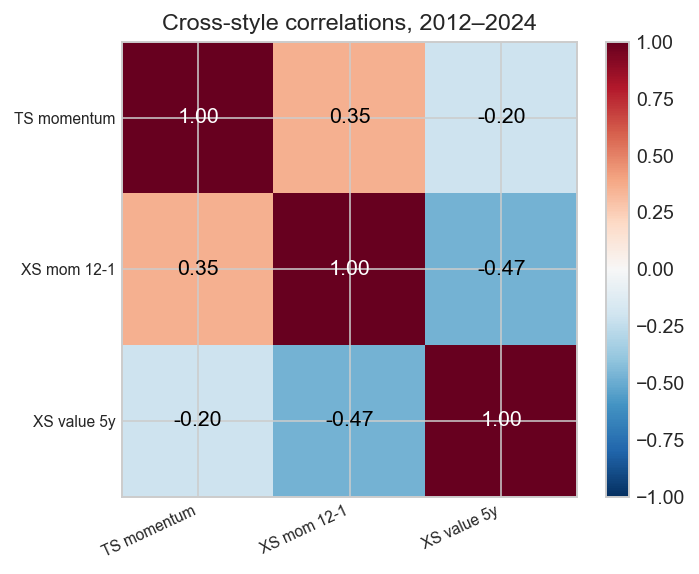

In [4]:
style_cols = ["TS momentum", "XS mom 12-1", "XS value 5y"]
corr = aligned[style_cols].corr()
print("Style return correlations (aligned window)")
display(corr.round(3))

fig, ax = plt.subplots(figsize=(5.2, 4.2), dpi=140)
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(3), style_cols, rotation=25, ha="right", fontsize=8)
ax.set_yticks(range(3), style_cols, fontsize=8)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=11,
                color="white" if abs(corr.iloc[i, j]) > 0.55 else "black")
fig.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Cross-style correlations, 2012–2024")
fig.tight_layout()
plt.show()


## 4. Equal-volatility blends

Each sleeve is already scaled to 15%. An equal-weight average is therefore an equal-risk blend. The blend is then scaled back to 15% so any diversification shows up as return rather than as unused risk budget.

Two portfolios: **momentum-only** (TS + XS 12-1) and **momentum + value** (those two plus 5-year reversal). If Baz et al.'s mechanism survives this sample, the three-style book should have lower correlation-implied vol and a higher vol-targeted Sharpe. If value's realized Sharpe is sufficiently negative, the mechanism is still there in the correlation matrix and still loses money.


In [5]:
def blend_and_scale(frame: pd.DataFrame) -> pd.Series:
    raw = frame.mean(axis=1)
    return vol_target(raw)


mom_only = blend_and_scale(aligned[["TS momentum", "XS mom 12-1"]]).dropna()
mom_val = blend_and_scale(aligned[style_cols]).dropna()
spy = aligned["S&P 500 (SPY)"]

blends = {
    "TS + XS momentum": mom_only,
    "TS + XS + value": mom_val,
    "TS momentum": aligned["TS momentum"],
    "XS mom 12-1": aligned["XS mom 12-1"],
    "XS value 5y": aligned["XS value 5y"],
    "S&P 500 (SPY)": spy,
}
print("Equal-vol blends vs. sleeves, same window")
display(stats_table(blends))

# realized blend vol before the final scale, as a check on the diversification identity
raw_mom = aligned[["TS momentum", "XS mom 12-1"]].mean(axis=1)
raw_3 = aligned[style_cols].mean(axis=1)
print(
    f"Pre-scale ann. vol  mom-only blend: {np.sqrt(TRADING_DAYS) * raw_mom.std():.1%}   "
    f"(sleeve avg {np.sqrt(TRADING_DAYS) * aligned[['TS momentum','XS mom 12-1']].std().mean():.1%})"
)
print(
    f"Pre-scale ann. vol  3-style blend:  {np.sqrt(TRADING_DAYS) * raw_3.std():.1%}   "
    f"(sleeve avg {np.sqrt(TRADING_DAYS) * aligned[style_cols].std().mean():.1%})"
)


Equal-vol blends vs. sleeves, same window


,TS + XS momentum,TS + XS + value,TS momentum,XS mom 12-1,XS value 5y,S&P 500 (SPY)
Ann. Return,8.3%,5.9%,8.8%,6.4%,-8.4%,13.6%
Ann. Vol,15.5%,15.5%,15.4%,15.4%,15.4%,16.7%
Sharpe,0.60,0.44,0.62,0.48,-0.49,0.85
Sortino,0.83,0.62,0.86,0.68,-0.69,1.19
Max DD,-26.3%,-31.1%,-20.5%,-40.7%,-70.1%,-33.7%
Calmar,0.32,0.19,0.43,0.16,-0.12,0.40
Avg DD (days),171,192,132,340,754,97
Longest DD (days),495,740,421,2118,2679,488


Pre-scale ann. vol  mom-only blend: 12.7%   (sleeve avg 15.4%)
Pre-scale ann. vol  3-style blend:  7.9%   (sleeve avg 15.4%)


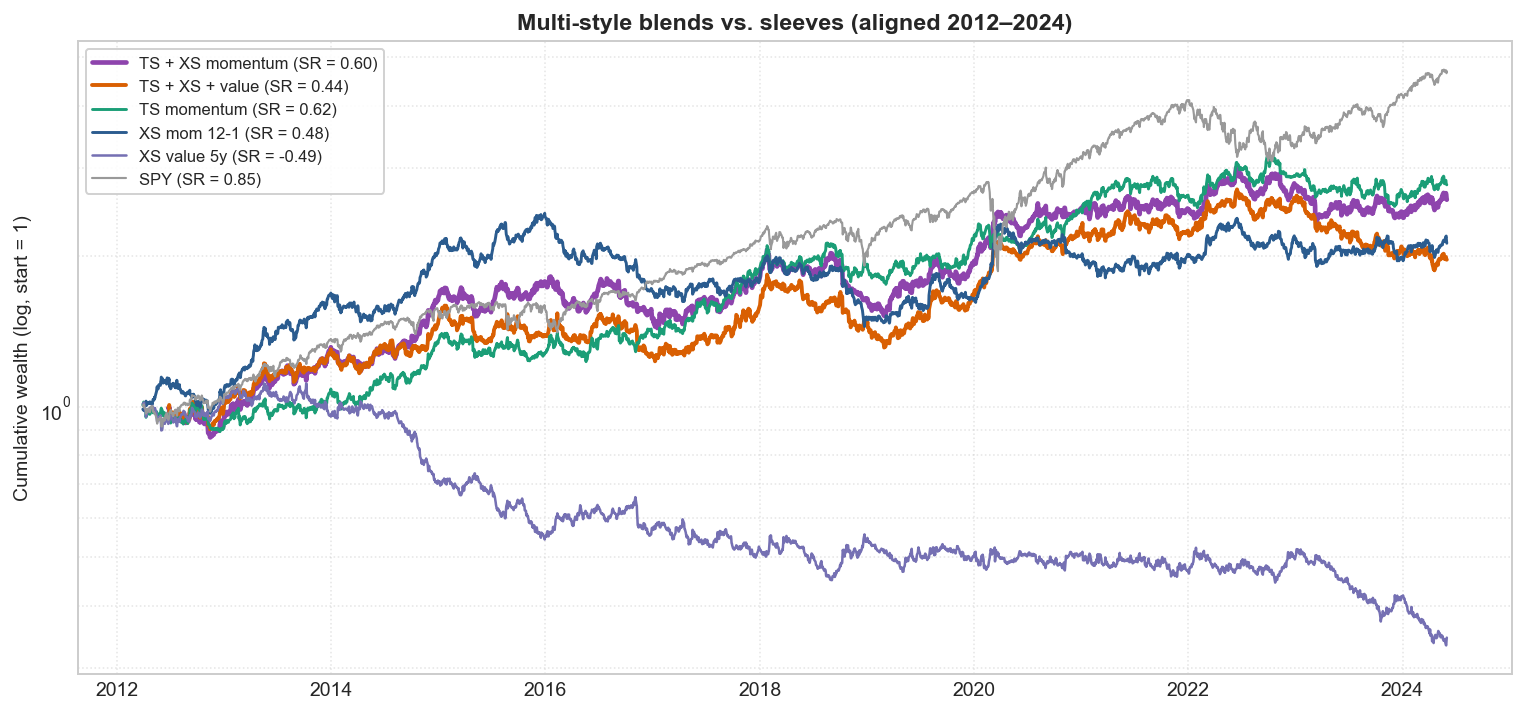

In [6]:
def wealth(r):
    return (1 + r.dropna()).cumprod()


def sr(r):
    r = r.dropna()
    return np.sqrt(TRADING_DAYS) * r.mean() / r.std()


fig, ax = plt.subplots(figsize=(11, 5.2), dpi=140)
series = [
    ("TS + XS momentum", mom_only, "#8e44ad", 2.4),
    ("TS + XS + value", mom_val, "#d95f02", 2.0),
    ("TS momentum", aligned["TS momentum"], "#1b9e77", 1.5),
    ("XS mom 12-1", aligned["XS mom 12-1"], "#2b5c8f", 1.5),
    ("XS value 5y", aligned["XS value 5y"], "#7570b3", 1.3),
    ("SPY", spy, "#999999", 1.1),
]
for name, r, color, lw in series:
    ax.plot(wealth(r), label=f"{name} (SR = {sr(r):.2f})", color=color, lw=lw)
ax.set_yscale("log")
ax.set_title("Multi-style blends vs. sleeves (aligned 2012–2024)", fontsize=12, fontweight="bold")
ax.set_ylabel("Cumulative wealth (log, start = 1)")
ax.legend(loc="upper left", fontsize=8.5, frameon=True, facecolor="white", framealpha=0.9)
ax.grid(True, which="both", ls=":", alpha=0.5)
fig.tight_layout()
plt.show()


## 5. Is value broken, or is this window?

Ken French's HML is the same economic idea — long cheap, short expensive — measured with book-to-market on US stocks, monthly, since 1926. If 5-year reversal on 10 ETFs in 2012–2024 is a bad sample rather than a bad specification, HML should look ordinary over a century and poor over the same 2012–2024 window. Loaded from the cached Fama–French file next to `03_factor_momentum.ipynb`; no new download.


In [7]:
ff_path = Path("../factor_models/data_cache/ff_FF3.pkl")
ff3 = pd.read_pickle(ff_path)
hml = ff3["HML"]
hml_long = hml.dropna()
hml_win = hml.loc[aligned.index[0]: aligned.index[-1]]


def monthly_sr(r):
    r = r.dropna()
    return np.sqrt(12) * r.mean() / r.std(), len(r), r.index[0].strftime("%Y-%m"), r.index[-1].strftime("%Y-%m")


rows = {}
for label, series in (("HML 1926–", hml_long), ("HML in the ETF window", hml_win)):
    s, n, a, b = monthly_sr(series)
    wealth_m = (1 + series.dropna()).cumprod()
    mdd = (wealth_m / wealth_m.cummax() - 1).min()
    rows[label] = {
        "Window": f"{a} → {b}",
        "Months": n,
        "Sharpe": f"{s:.2f}",
        "Ann. mean": f"{100 * 12 * series.mean():.1f}%",
        "Max DD": f"{100 * mdd:.1f}%",
    }
print("HML on the long file vs. the 2012–2024 window that the ETF value book actually trades")
display(pd.DataFrame(rows))


HML on the long file vs. the 2012–2024 window that the ETF value book actually trades


,HML 1926–,HML in the ETF window
Window,1926-07 → 2026-06,2012-03 → 2024-05
Months,1200,147
Sharpe,0.35,-0.06
Ann. mean,4.3%,-0.8%
Max DD,-57.8%,-51.3%


## 6. Statistical significance

HAC $t$, Mertens Sharpe intervals, stationary bootstrap, BH across the sleeves-and-blends set. Jobson–Korkie tests answer the questions the paper poses: does adding value beat momentum-only, and does momentum-only beat either sleeve alone?


In [8]:
def newey_west_tstat(returns: pd.Series):
    r = returns.dropna().to_numpy(dtype=float)
    T = len(r)
    lags = int(np.floor(4 * (T / 100) ** (2 / 9)))
    e = r - r.mean()
    var = e @ e / T
    for lag in range(1, lags + 1):
        var += 2 * (1 - lag / (lags + 1)) * (e[lag:] @ e[:-lag]) / T
    t_stat = r.mean() / np.sqrt(var / T)
    return t_stat, 2 * stats.norm.sf(abs(t_stat)), lags


def sharpe_standard_error(returns: pd.Series) -> float:
    r = returns.dropna().to_numpy(dtype=float)
    sr_d = r.mean() / r.std(ddof=1)
    skew, kurt = stats.skew(r), stats.kurtosis(r, fisher=False)
    var = (1 + 0.5 * sr_d ** 2 - skew * sr_d + (kurt - 3) / 4 * sr_d ** 2) / len(r)
    return np.sqrt(var * TRADING_DAYS)


def bootstrap_sharpe_ci(returns: pd.Series, n_boot=1000, mean_block=21, seed=0):
    rng = np.random.default_rng(seed)
    r = returns.dropna().to_numpy(dtype=float)
    T = len(r)
    idx = np.empty((n_boot, T), dtype=np.int64)
    idx[:, 0] = rng.integers(0, T, n_boot)
    restart = rng.random((n_boot, T)) < 1 / mean_block
    fresh = rng.integers(0, T, (n_boot, T))
    for t in range(1, T):
        idx[:, t] = np.where(restart[:, t], fresh[:, t], (idx[:, t - 1] + 1) % T)
    draws = r[idx]
    sr_b = np.sqrt(TRADING_DAYS) * draws.mean(axis=1) / draws.std(axis=1, ddof=1)
    return np.quantile(sr_b, 0.025), np.quantile(sr_b, 0.975)


def sharpe_difference_test(a: pd.Series, b: pd.Series):
    paired = pd.concat([a, b], axis=1, join="inner").dropna()
    x, y = paired.iloc[:, 0].to_numpy(), paired.iloc[:, 1].to_numpy()
    T = len(x)
    sr_a, sr_b = x.mean() / x.std(ddof=1), y.mean() / y.std(ddof=1)
    rho = np.corrcoef(x, y)[0, 1]
    theta = (2 * (1 - rho) + 0.5 * (sr_a ** 2 + sr_b ** 2 - 2 * rho ** 2 * sr_a * sr_b)) / T
    z = (sr_a - sr_b) / np.sqrt(theta)
    return z, 2 * stats.norm.sf(abs(z)), rho


sig_set = blends
rows = []
nw_lags = None
for name, r in sig_set.items():
    sharpe = np.sqrt(TRADING_DAYS) * r.mean() / r.std()
    se = sharpe_standard_error(r)
    t_stat, p_value, nw_lags = newey_west_tstat(r)
    lo, hi = bootstrap_sharpe_ci(r)
    rows.append({
        "Sharpe": f"{sharpe:.2f}",
        "SE": f"{se:.2f}",
        "95% CI (boot)": f"[{lo:.2f}, {hi:.2f}]",
        "HAC t": f"{t_stat:.2f}",
        "p-value": p_value,
    })
sig = pd.DataFrame(rows, index=list(sig_set))
sig["BH p"] = stats.false_discovery_control(sig["p-value"], method="bh")
for col in ("p-value", "BH p"):
    sig[col] = sig[col].map(lambda v: f"{v:.3f}")
years = len(next(iter(sig_set.values()))) / TRADING_DAYS
print(f"Aligned sample: {years:.1f} years, L = {nw_lags}, Sharpe for t = 2: {2 / np.sqrt(years):.2f}")
display(sig.T)

pairs = [
    ("Mom-only vs TS momentum", mom_only, aligned["TS momentum"]),
    ("Mom-only vs XS mom 12-1", mom_only, aligned["XS mom 12-1"]),
    ("Mom+value vs mom-only", mom_val, mom_only),
    ("Mom+value vs value", mom_val, aligned["XS value 5y"]),
    ("Mom-only vs SPY", mom_only, spy),
]
diff_rows = {}
for label, a, b in pairs:
    z, p, rho = sharpe_difference_test(a, b)
    sa = np.sqrt(TRADING_DAYS) * a.mean() / a.std()
    sb = np.sqrt(TRADING_DAYS) * b.mean() / b.std()
    diff_rows[label] = {
        "SR A": f"{sa:.2f}", "SR B": f"{sb:.2f}", "Diff": f"{sa - sb:+.2f}",
        "Corr": f"{rho:.2f}", "JK z": f"{z:.2f}", "p": f"{p:.3f}",
    }
print("Jobson-Korkie: did the blend beat the sleeve it was supposed to improve on?")
display(pd.DataFrame(diff_rows))


Aligned sample: 11.9 years, L = 8, Sharpe for t = 2: 0.58


,TS + XS momentum,TS + XS + value,TS momentum,XS mom 12-1,XS value 5y,S&P 500 (SPY)
Sharpe,0.60,0.44,0.62,0.48,-0.49,0.85
SE,0.29,0.29,0.29,0.29,0.29,0.29
95% CI (boot),"[0.02, 1.19]","[-0.09, 0.97]","[0.14, 1.10]","[-0.14, 1.08]","[-1.04, -0.03]","[0.32, 1.40]"
HAC t,2.15,1.57,2.32,1.67,-1.91,3.31
p-value,0.032,0.115,0.020,0.096,0.056,0.001
BH p,0.063,0.115,0.061,0.115,0.084,0.006


Jobson-Korkie: did the blend beat the sleeve it was supposed to improve on?


,Mom-only vs TS momentum,Mom-only vs XS mom 12-1,Mom+value vs mom-only,Mom+value vs value,Mom-only vs SPY
SR A,0.60,0.60,0.44,0.44,0.60
SR B,0.62,0.48,0.60,-0.49,0.85
Diff,-0.03,+0.12,-0.15,+0.94,-0.25
Corr,0.82,0.81,0.82,0.14,0.15
JK z,-0.33,1.00,-0.86,2.39,-0.78
p,0.740,0.317,0.389,0.017,0.435


### What the tests actually say

Three facts, in order of how easy they are to over-read.

**The correlation matrix does what Baz et al. said it would.** Value vs. TS momentum is $-0.20$; value vs. XS 12-1 momentum is $-0.47$. Pre-scale annualized vol of the three-style blend is $7.9\%$ against a $15.4\%$ average of the sleeves (momentum-only: $12.7\%$ against $15.4\%$). That is the diversification identity, and it does not require value to have a positive Sharpe.

**Adding value still hurts.** The 5-year reversal prints Sharpe $-0.49$ (max drawdown $-70\%$), and its bootstrap interval, $[-1.04, -0.03]$, sits just below zero. Vol-targeting the three-style blend recovers the vol and produces Sharpe $0.44$, below momentum-only at $0.60$. Jobson–Korkie of momentum+value vs. momentum-only is $z = -0.86$, $p = 0.39$: we cannot even reject that adding value did nothing, and the point estimate says it hurt. Momentum-only itself is indistinguishable from TS momentum alone ($p = 0.74$, and the point estimate is slightly *lower*: $0.60$ vs. $0.62$) and from SPY ($p = 0.44$).

**Nothing here clears the multiple-testing bar.** TS momentum has the best case ($t = 2.32$, raw $p = 0.020$) and its Benjamini–Hochberg $p$ is $0.061$; the momentum-only blend is at $0.063$. Twelve years is short: the Sharpe needed for $t = 2$ is $0.58$, and TS momentum's $0.62$ only just exceeds it. The same engine passes on the 16-year window in `momentum_strategies.ipynb`, which says more about sample length than about the strategy.

**HML on 1926– vs. 2012– is the sanity check, and it agrees.** Long-sample HML Sharpe is $0.35$; over the same 2012–2024 window it is $-0.06$. The ETF reversal is a noisier version of the same decade, not a broken proxy. Twelve years of 10 names is also well below the power we had for factor momentum (Sharpe-for-$t=2$ of $0.58$ here vs. $0.20$ on a century of monthly factors). Carry remains omitted on purpose.